# Spatial Analysis of Culture and Economic Development in India (32 States)

This notebook examines the relationship between economic development (nighttime lights per capita, 1992) and cultural participation (NSS 47th Round, July–December 1991) across all 32 Indian states and union territories.

### Data sources

- **Nighttime lights (NTL):** Consistent and Corrected Nighttime Light dataset (CCNL 1992-2013) derived from DMSP-OLS satellite imagery (Zhao, Cao, Chen, & Cui, 2022; Zenodo doi:[10.5281/zenodo.6644980](https://doi.org/10.5281/zenodo.6644980)). Also accessible via Google Earth Engine as `BNU/FGS/CCNL/v1`. Population data from the GlobPOP Global Gridded Population dataset (1992). Zonal statistics were computed at each dataset's native spatial resolution via GEE (see `data/ntl/GEE_ntl_percapita_1992.js`).
- **Cultural participation:** National Sample Survey (NSS) 47th Round (July -- December 1991), Schedule 30, conducted by the Central Statistics Office of India. This household-level survey covers cultural participation across multiple dimensions. Six cultural factors were derived via Principal Component Analysis (PCA) following the Culture-Based Development framework of Tubadji (2025).
- **Geographic boundaries:** 32-region map derived from a 36-region GeoJSON by dissolving four states created after the survey period (Chhattisgarh, Jharkhand, Uttarakhand, Telangana) into their parent states.

## 1. Setup and Data Loading

### Variable definitions

**Economic development proxy:**

| Variable | Description | Source | Construction |
|---|---|---|---|
| `ln_ntl_pc` | Log NTL per capita (1992) | CCNL DMSP-OLS via GEE | `log(sum_ntl / pop_mil)` where `sum_ntl` = total radiance-calibrated DN summed over the state, `pop_mil` = GlobPOP population in millions. Note: dividing by population in millions rather than population in persons adds a constant (log 10^6) that cancels in all correlation and regression analyses. |

**Cultural participation variables** (PCA factor scores, standardized, aggregated to state means):

| Variable | Label | Interpretation |
|---|---|---|
| `LC_Performance` | Live Cultural Performance | Theater, classical dance, music attendance |
| `LC_Telecast` | Cultural Telecast (TV/Media) | Cultural content consumed via television and media |
| `SC` | Socio-Cultural Participation | Community-based cultural engagement |
| `CH_relig` | Cultural Heritage & Religion | Religious and traditional cultural participation |
| `LC_shows` | Live Cultural Shows | Commercial entertainment and show attendance |
| `Sports` | Sports Participation | Participation in sporting events |

The six cultural factors were extracted via Principal Component Analysis (PCA) with varimax rotation on 20 survey items (B7_q3 through B7_q20) from NSS Schedule 30.
Predicted factor scores were then collapsed to state-level means (see `data/Cultural_Data_India/CulturalData.do`).

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from libpysal import weights
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import contextily as cx


In [ ]:
# Load cultural data (NSS 47th Round, July-December 1991)
df_culture = pd.read_stata("../data/Cultural_Data_India/Final_state_LC_CH.dta")
print(f"Cultural data: {df_culture.shape[0]} states, {df_culture.shape[1]} columns")

# Load NTL per capita data (1992, 32 states)
df_ntl = pd.read_csv("../data/ntl/india32_ntl_percapita_1992.csv")
print(f"NTL data: {df_ntl.shape[0]} states, {df_ntl.shape[1]} columns")

# Load 32-region map
gdf32 = gpd.read_file("../data/maps/india32.geojson")
print(f"Map: {len(gdf32)} regions")

Cultural data: 32 states, 7 columns
NTL data: 32 states, 6 columns
Map: 32 regions


In [ ]:
# Merge all three datasets
gdf = gdf32.merge(df_culture, left_on="region", right_on="State_num", how="left")
gdf = gdf.merge(df_ntl[["region", "ln_ntl_pc"]], on="region", how="left")

# Check merge completeness
n_culture = gdf["State_num"].notna().sum()
n_ntl = gdf["ln_ntl_pc"].notna().sum()
print(f"States with cultural data: {n_culture}/32")
print(f"States with NTL data: {n_ntl}/32")

# Define variables and descriptive labels
variables = ["LC_Performance", "LC_Telecast", "SC", "CH_relig", "LC_shows", "Sports"]
var_labels = {
    "LC_Performance": "Live Cultural Performance",
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "SC": "Socio-Cultural Participation",
    "CH_relig": "Cultural Heritage & Religion",
    "LC_shows": "Live Cultural Shows",
    "Sports": "Sports Participation",
}

print(f"\nLog NTL per capita: range [{gdf['ln_ntl_pc'].min():.3f}, {gdf['ln_ntl_pc'].max():.3f}]")
print(f"Mean: {gdf['ln_ntl_pc'].mean():.3f}, Std: {gdf['ln_ntl_pc'].std():.3f}")

States with cultural data: 32/32
States with NTL data: 32/32

Log NTL per capita: range [6.713, 9.608]
Mean: 8.286, Std: 0.768


### Data merge summary

- **Merge completeness:** 32/32 states matched for both cultural and NTL datasets --- no missing observations.
- **Temporal alignment:** The cultural survey (July -- December 1991) and the NTL satellite imagery (1992 annual composite) cover adjacent periods. Cultural participation patterns and regional luminosity are structural characteristics that change slowly, making this cross-sectional comparison appropriate.
- **Sample size:** N = 32 states and union territories, representing full coverage of Indian administrative units at the time of the survey.

## 2. Choropleth Maps --- Log NTL vs Cultural Variables

Comparing the spatial distribution of economic development (log NTL per capita) with key cultural participation variables across all 32 states.
Similar geographic clustering across maps may indicate spatial association between luminosity and cultural patterns, which is tested formally in Section 5.

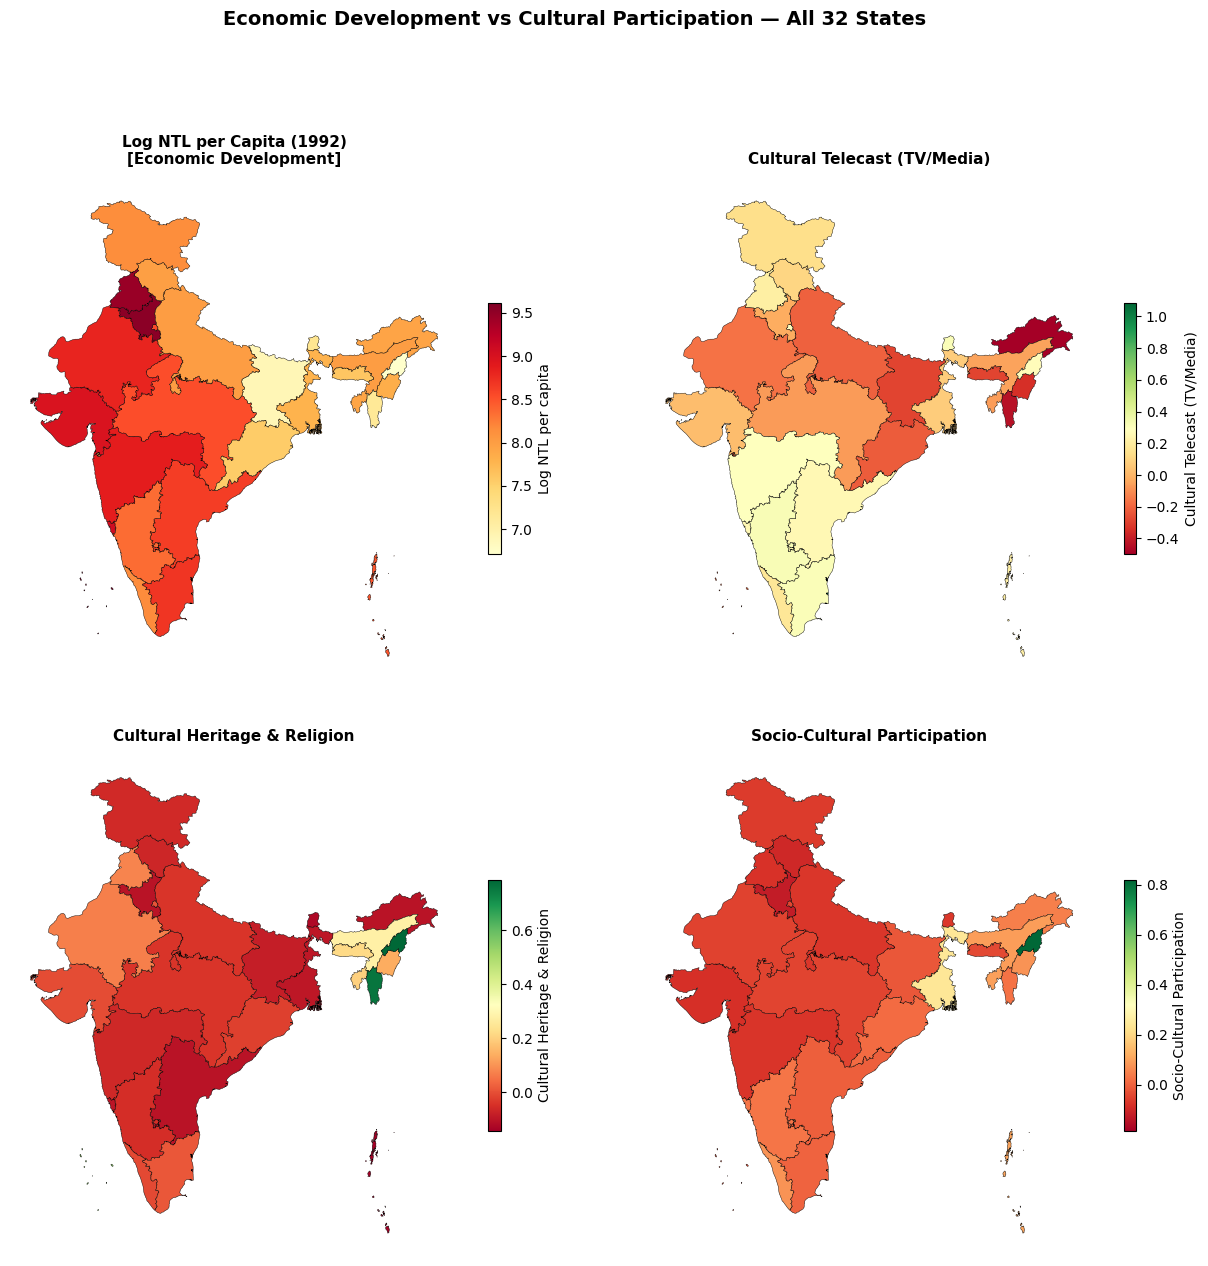

In [ ]:
cultural_compare = ["LC_Telecast", "CH_relig", "SC"]
cultural_labels = {
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "CH_relig": "Cultural Heritage & Religion",
    "SC": "Socio-Cultural Participation",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Log NTL per capita map
gdf.plot(
    column="ln_ntl_pc", ax=axes[0], legend=True,
    legend_kwds={"shrink": 0.5, "label": "Log NTL per capita"},
    cmap="YlOrRd", edgecolor="black", linewidth=0.3,
    missing_kwds={"color": "lightgray"},
)
axes[0].set_title("Log NTL per Capita (1992)\n[Economic Development]",
                  fontsize=11, fontweight="bold", pad=10)
axes[0].set_axis_off()

# Cultural maps
for i, var in enumerate(cultural_compare):
    gdf.plot(
        column=var, ax=axes[i + 1], legend=True,
        legend_kwds={"shrink": 0.5, "label": cultural_labels[var]},
        cmap="RdYlGn", edgecolor="black", linewidth=0.3,
        missing_kwds={"color": "lightgray"},
    )
    axes[i + 1].set_title(cultural_labels[var], fontsize=11, fontweight="bold", pad=10)
    axes[i + 1].set_axis_off()

fig.suptitle(
    "Economic Development vs Cultural Participation \u2014 All 32 States",
    fontsize=14, fontweight="bold", y=1.0,
)
fig.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()

## 3. Scatter Plots — Log NTL vs Cultural Variables

Each scatter plot shows the relationship between log NTL per capita (x-axis) and a cultural participation variable (y-axis) for all 32 states.

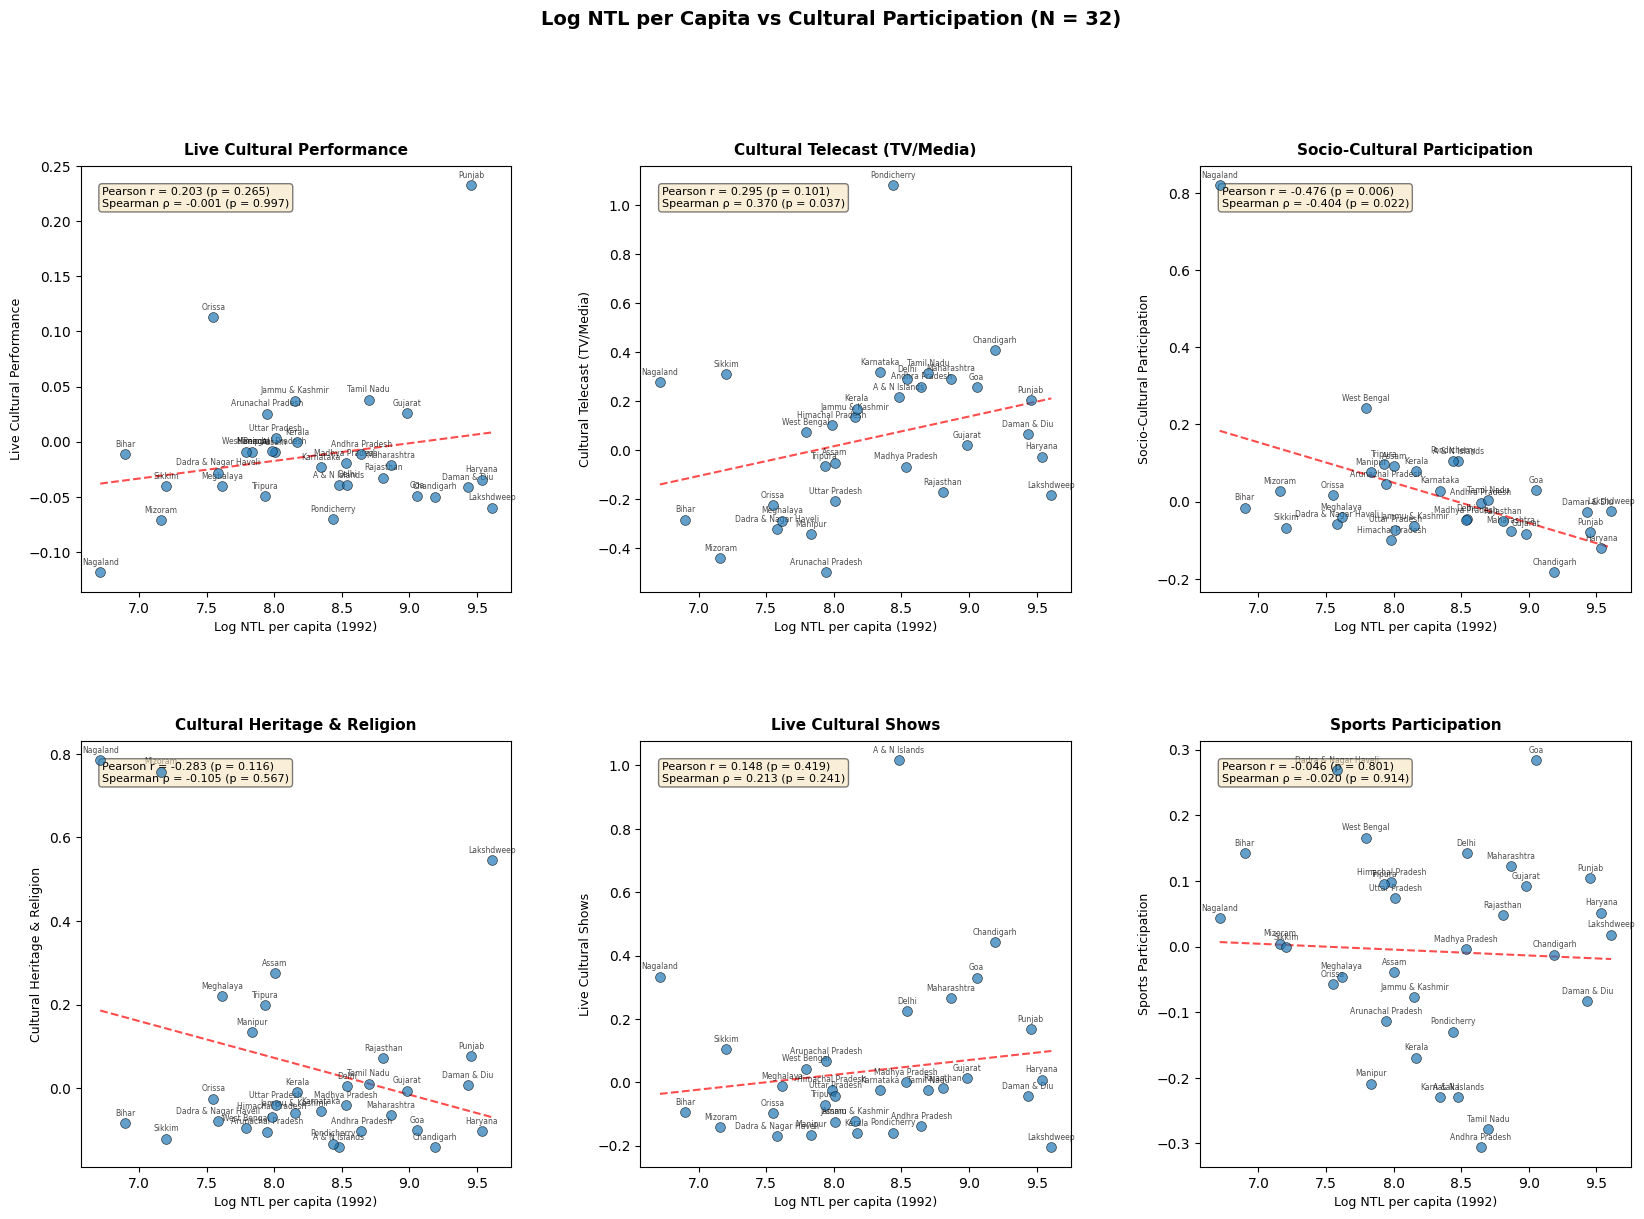

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    x = gdf["ln_ntl_pc"]
    y = gdf[var]

    ax.scatter(x, y, s=50, alpha=0.7, edgecolors="black", linewidth=0.5, zorder=5)

    # Label each point with state name
    for _, row in gdf.iterrows():
        ax.annotate(
            row["region"], (row["ln_ntl_pc"], row[var]),
            fontsize=5.5, alpha=0.7, ha="center", va="bottom",
            xytext=(0, 4), textcoords="offset points",
        )

    # Regression line
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, intercept + slope * x_line, "r--", alpha=0.7, linewidth=1.5)

    # Spearman correlation
    rho, p_spearman = stats.spearmanr(x, y)

    ax.set_title(var_labels[var], fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Log NTL per capita (1992)", fontsize=9)
    ax.set_ylabel(var_labels[var], fontsize=9)
    ax.text(
        0.05, 0.95,
        f"Pearson r = {r_val:.3f} (p = {p_val:.3f})\nSpearman \u03c1 = {rho:.3f} (p = {p_spearman:.3f})",
        transform=ax.transAxes, fontsize=8, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

fig.suptitle(
    "Log NTL per Capita vs Cultural Participation (N = 32)",
    fontsize=14, fontweight="bold", y=1.0,
)
fig.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()

## 4. Correlation Analysis

Pearson and Spearman correlation matrices, plus a significance table comparing all cultural variables with log NTL per capita.
Both coefficients are reported because Pearson captures linear association while Spearman captures monotonic relationships and is robust to outliers --- an important consideration with N = 32 and potential leverage from small island territories at the extremes of the NTL distribution.
For the manuscript, we adopt Spearman as the primary measure given these outlier concerns.

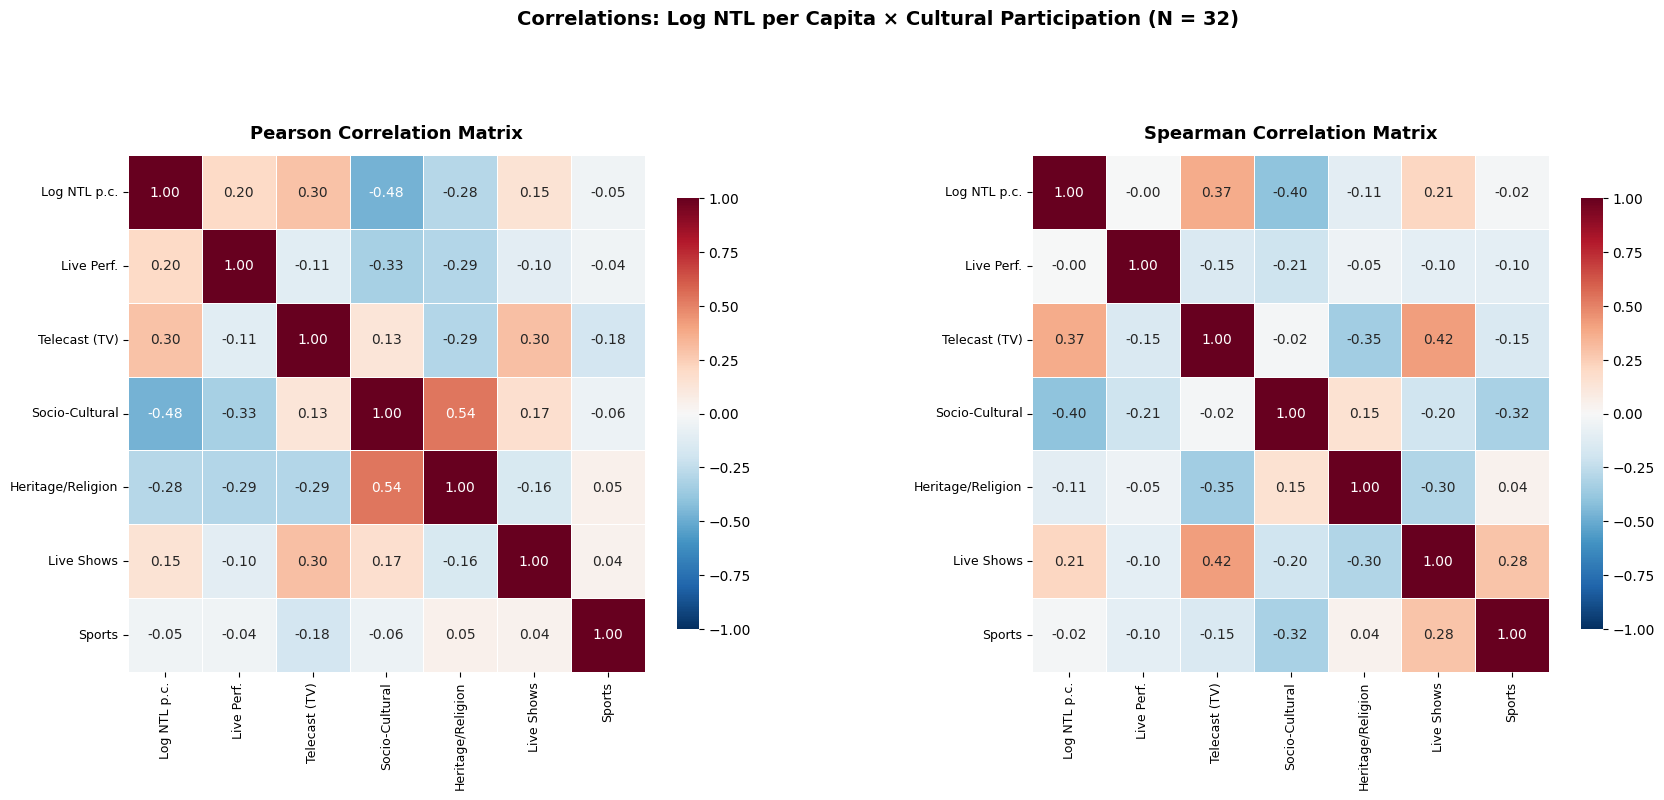

In [ ]:
corr_vars = ["ln_ntl_pc"] + variables
corr_labels = {
    "ln_ntl_pc": "Log NTL p.c.",
    "LC_Performance": "Live Perf.",
    "LC_Telecast": "Telecast (TV)",
    "SC": "Socio-Cultural",
    "CH_relig": "Heritage/Religion",
    "LC_shows": "Live Shows",
    "Sports": "Sports",
}

corr_pearson = gdf[corr_vars].corr(method="pearson")
corr_spearman = gdf[corr_vars].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman"]):
    corr_display = corr.copy()
    corr_display.index = [corr_labels.get(v, v) for v in corr_display.index]
    corr_display.columns = [corr_labels.get(v, v) for v in corr_display.columns]

    sns.heatmap(
        corr_display, annot=True, fmt=".2f", cmap="RdBu_r",
        vmin=-1, vmax=1, center=0, ax=ax, square=True,
        linewidths=0.5, cbar_kws={"shrink": 0.7},
        annot_kws={"fontsize": 10},
    )
    ax.set_title(f"{title} Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=9)

fig.suptitle(
    "Correlations: Log NTL per Capita \u00d7 Cultural Participation (N = 32)",
    fontsize=14, fontweight="bold", y=1.0,
)
fig.subplots_adjust(wspace=0.4)
plt.show()

In [ ]:
# Significance table
print("Correlation of Log NTL per Capita (1992) with Cultural Variables")
print("=" * 75)
print("{:<35} {:>10} {:>10} {:>12} {:>10}".format(
    "Variable", "Pearson r", "p-value", "Spearman \u03c1", "p-value"))
print("-" * 75)

for var in variables:
    x = gdf["ln_ntl_pc"]
    y = gdf[var]
    r, p_r = stats.pearsonr(x, y)
    rho, p_rho = stats.spearmanr(x, y)
    sig_r = "*" if p_r < 0.05 else (" ." if p_r < 0.10 else "  ")
    sig_rho = "*" if p_rho < 0.05 else (" ." if p_rho < 0.10 else "  ")
    label = var_labels[var]
    print(f"{label:<35} {r:>9.3f}{sig_r} {p_r:>9.3f} {rho:>11.3f}{sig_rho} {p_rho:>9.3f}")

print("-" * 75)
print("Significance: * p < 0.05, . p < 0.10")
print(f"N = {len(gdf)} states")

Correlation of Log NTL per Capita (1992) with Cultural Variables
Variable                             Pearson r    p-value   Spearman ρ    p-value
---------------------------------------------------------------------------
Live Cultural Performance               0.203       0.265      -0.001       0.997
Cultural Telecast (TV/Media)            0.295       0.101       0.370*     0.037
Socio-Cultural Participation           -0.476*     0.006      -0.404*     0.022
Cultural Heritage & Religion           -0.283       0.116      -0.105       0.567
Live Cultural Shows                     0.148       0.419       0.213       0.241
Sports Participation                   -0.046       0.801      -0.020       0.914
---------------------------------------------------------------------------
Significance: * p < 0.05, . p < 0.10
N = 32 states


## 5. LISA Cluster Maps --- Log NTL vs Cultural Variables

Local Indicators of Spatial Association (LISA) for log NTL per capita and cultural variables.
Spatial weights: 6-nearest neighbors (k = 6), row-standardized. Permutations: 999, significance threshold: p < 0.05.

The choice of k = 6 follows the spatial weights specification used in the main convergence analysis (notebooks c03--c04), ensuring methodological consistency across the manuscript.

In [ ]:
# Build spatial weights matrix (6-nearest neighbors)
W = weights.KNN.from_dataframe(gdf, k=6)
W.transform = "r"
print(f"Spatial weights: {W.n} regions, k=6, row-standardized")
print("Note: KNN distances computed on WGS84 centroids. Island territories")
print("(A&N Islands, Lakshdweep) are linked to nearest mainland states by")
print("centroid distance, which may not reflect meaningful spatial adjacency.")

Spatial weights: 32 regions, k=6, row-standardized
Note: KNN distances computed on WGS84 centroids. Island territories
(A&N Islands, Lakshdweep) are linked to nearest mainland states by
centroid distance, which may not reflect meaningful spatial adjacency.


In [ ]:
# Global Moran's I for log NTL and all cultural variables
all_vars = ["ln_ntl_pc"] + variables
all_var_labels = {"ln_ntl_pc": "Log NTL per Capita (1992)"}
all_var_labels.update(var_labels)

print("Global Moran's I \u2014 Spatial Autocorrelation")
print("=" * 65)
print("{:<35} {:>10} {:>10} {:>12}".format(
    "Variable", "Moran I", "p-value", "Significant"))
print("-" * 65)

for var in all_vars:
    moran = Moran(gdf[var].values, W, permutations=999)
    sig = "Yes *" if moran.p_sim < 0.05 else ("Marginal ." if moran.p_sim < 0.10 else "No")
    label = all_var_labels[var]
    print(f"{label:<35} {moran.I:>9.3f} {moran.p_sim:>9.3f} {sig:>12}")

print("-" * 65)

Global Moran's I — Spatial Autocorrelation
Variable                               Moran I    p-value  Significant
-----------------------------------------------------------------
Log NTL per Capita (1992)               0.444     0.001        Yes *
Live Cultural Performance              -0.005     0.310           No
Cultural Telecast (TV/Media)            0.177     0.016        Yes *
Socio-Cultural Participation            0.188     0.002        Yes *
Cultural Heritage & Religion            0.248     0.006        Yes *
Live Cultural Shows                    -0.083     0.254           No
Sports Participation                    0.196     0.020        Yes *
-----------------------------------------------------------------


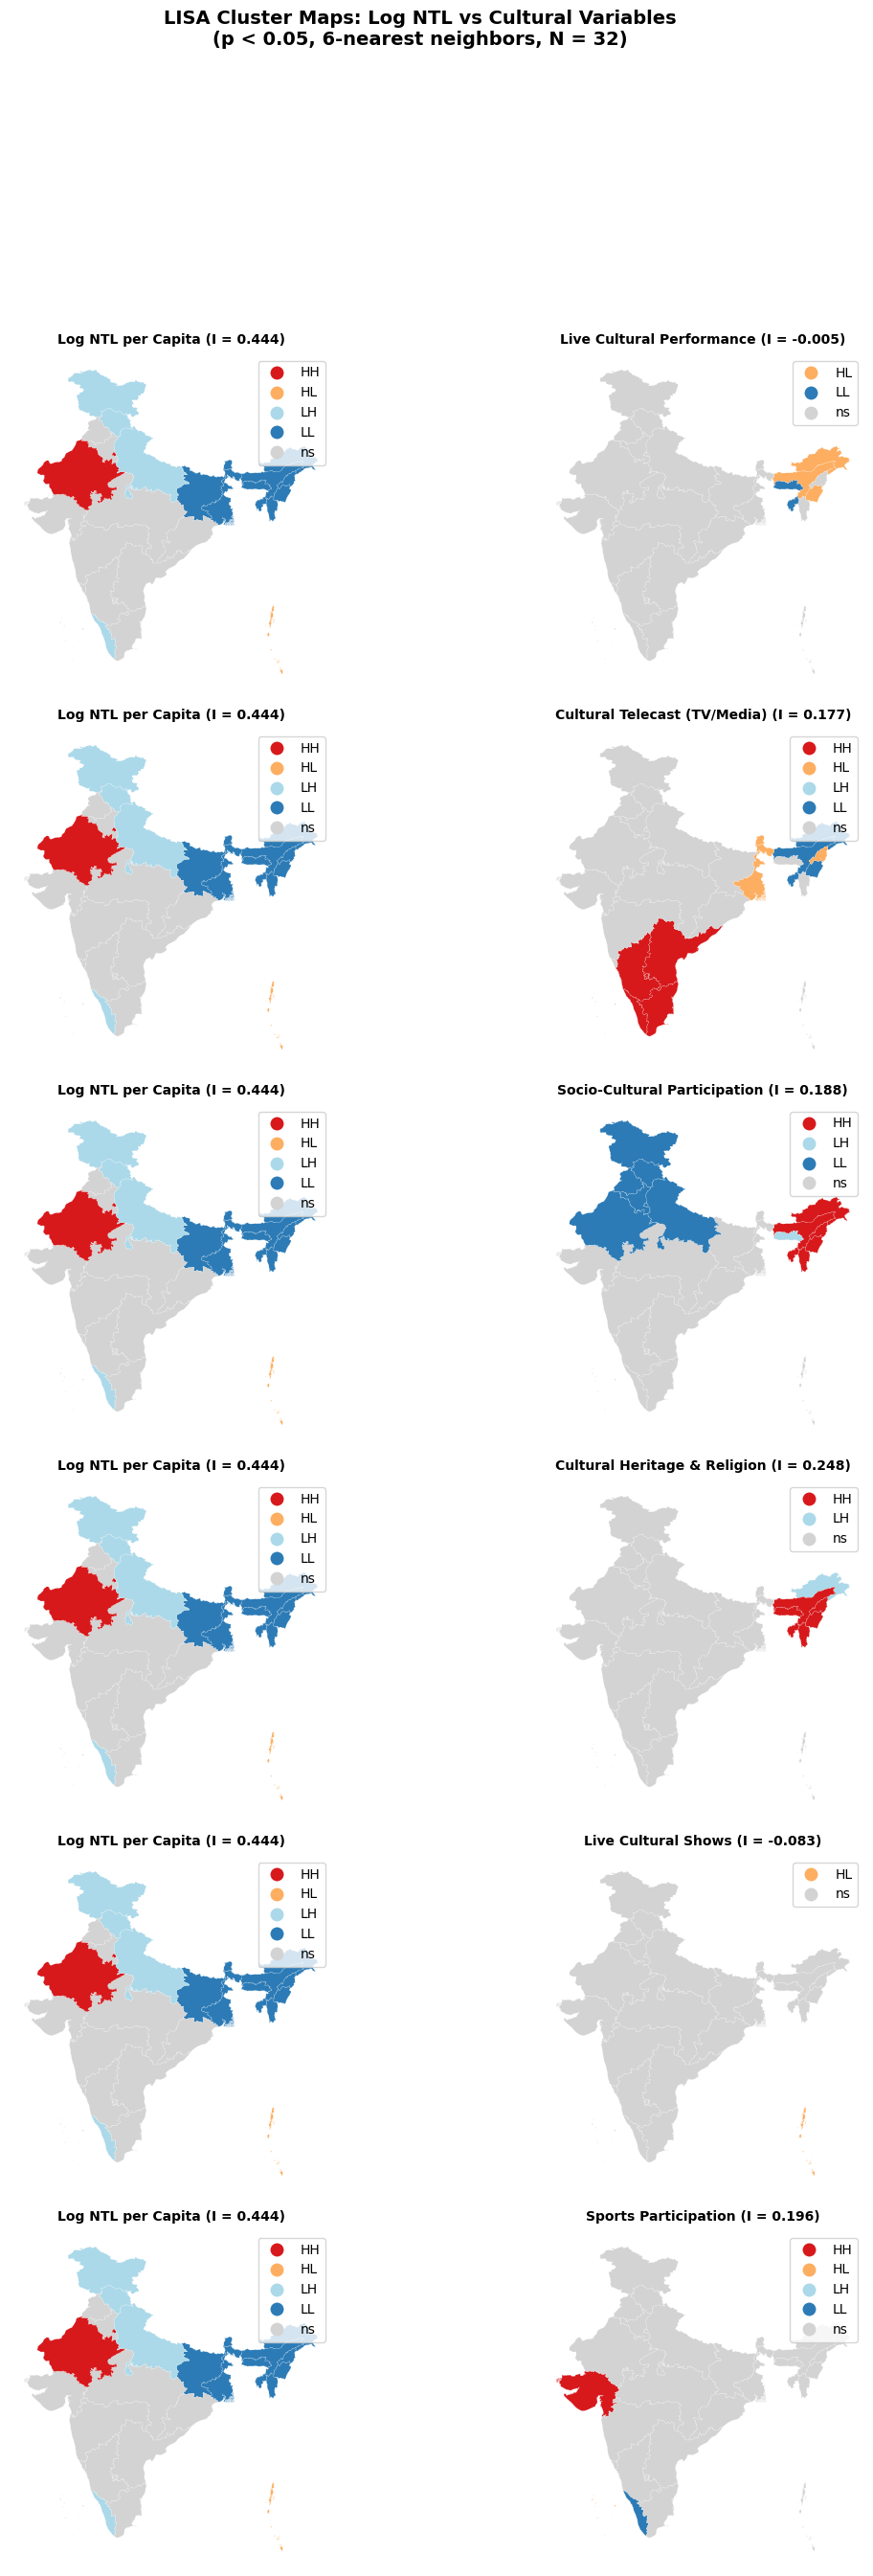

In [ ]:
# Compute LISA for log NTL and each cultural variable
lisa_ntl = Moran_Local(gdf["ln_ntl_pc"].values, W, permutations=999, seed=12345)

lisa_cultural = {}
for var in variables:
    lisa_cultural[var] = Moran_Local(gdf[var].values, W, permutations=999, seed=12345)

# Compute Global Moran I values for titles
moran_ntl_global = Moran(gdf["ln_ntl_pc"].values, W, permutations=999)
moran_cultural_global = {}
for var in variables:
    moran_cultural_global[var] = Moran(gdf[var].values, W, permutations=999)

# Side-by-side LISA cluster maps
fig, axes = plt.subplots(len(variables), 2, figsize=(14, 5 * len(variables)))

for i, var in enumerate(variables):
    # Left: NTL LISA
    lisa_cluster(lisa_ntl, gdf, p=0.05, ax=axes[i, 0])
    axes[i, 0].set_title(
        f"Log NTL per Capita (I = {moran_ntl_global.I:.3f})",
        fontsize=10, fontweight="bold", pad=8,
    )
    axes[i, 0].set_axis_off()

    # Right: Cultural variable LISA
    lisa_cluster(lisa_cultural[var], gdf, p=0.05, ax=axes[i, 1])
    axes[i, 1].set_title(
        f"{var_labels[var]} (I = {moran_cultural_global[var].I:.3f})",
        fontsize=10, fontweight="bold", pad=8,
    )
    axes[i, 1].set_axis_off()

fig.suptitle(
    "LISA Cluster Maps: Log NTL vs Cultural Variables\n(p < 0.05, 6-nearest neighbors, N = 32)",
    fontsize=14, fontweight="bold", y=1.0,
)
fig.subplots_adjust(hspace=0.12, wspace=0.05)
plt.show()

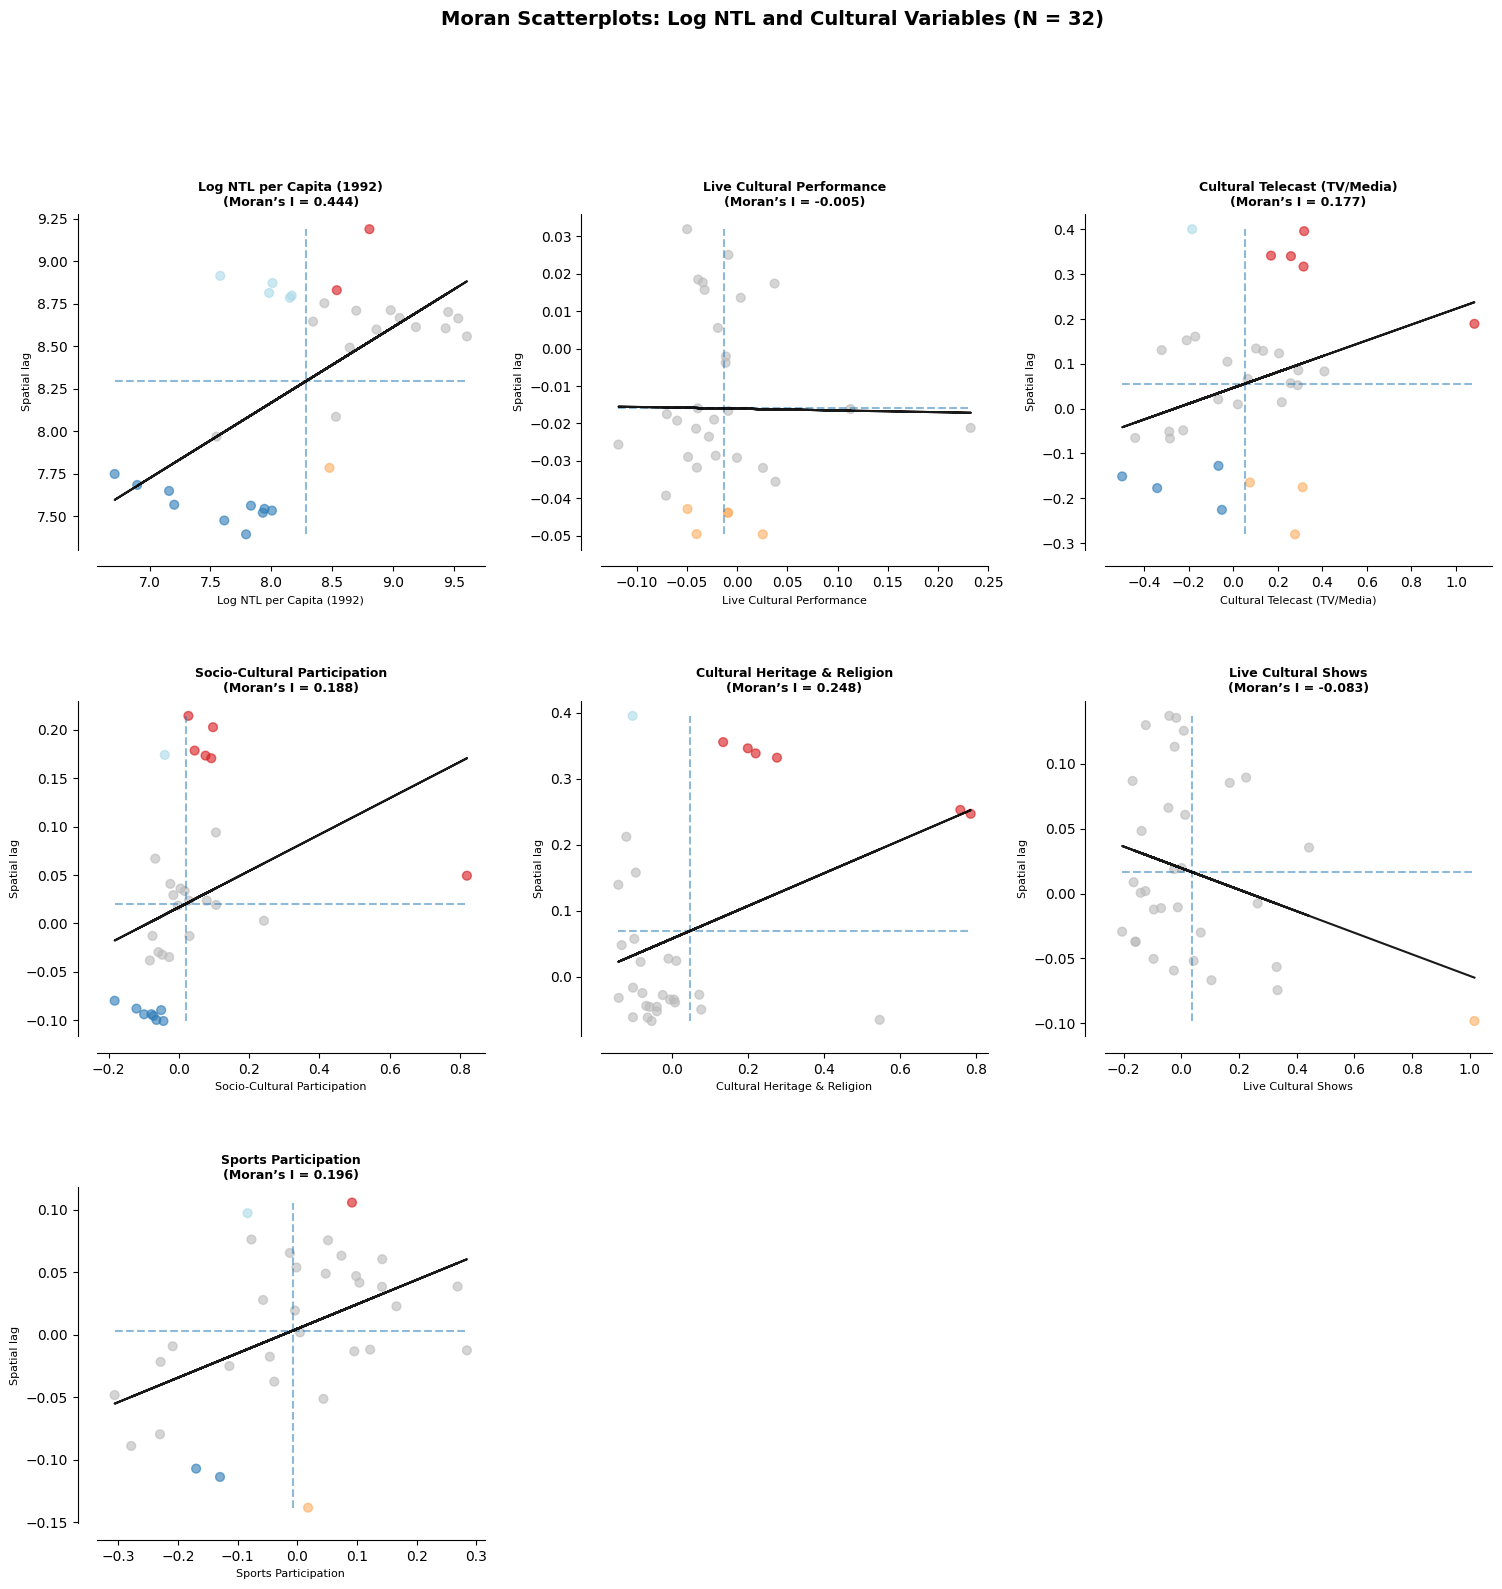

In [ ]:
# Moran scatterplots
all_lisa = {"ln_ntl_pc": lisa_ntl}
all_lisa.update(lisa_cultural)

all_labels = {"ln_ntl_pc": "Log NTL per Capita (1992)"}
all_labels.update(var_labels)

fig, axes = plt.subplots(3, 3, figsize=(18, 17))
axes = axes.flatten()

plot_vars = ["ln_ntl_pc"] + variables
for i, var in enumerate(plot_vars):
    moran_scatterplot(all_lisa[var], p=0.05, zstandard=False, aspect_equal=False, ax=axes[i])
    moran_global = Moran(gdf[var].values, W, permutations=999)
    axes[i].set_title(
        f"{all_labels[var]}\n(Moran\u2019s I = {moran_global.I:.3f})",
        fontsize=9, fontweight="bold", pad=6,
    )
    axes[i].set_xlabel(all_labels[var], fontsize=8)
    axes[i].set_ylabel("Spatial lag", fontsize=8)

# Hide unused axes
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Moran Scatterplots: Log NTL and Cultural Variables (N = 32)",
    fontsize=14, fontweight="bold", y=1.0,
)
fig.subplots_adjust(hspace=0.45, wspace=0.3)
plt.show()

## 6. High vs Low Development: Cultural Profiles

Comparing the average cultural participation of states above and below the median log NTL per capita.
This median split provides a non-parametric complement to the continuous correlation analysis, offering an intuitive summary of how cultural profiles differ between more and less economically developed states.

Median log NTL per capita: 8.257
High NTL group: 16 states
Low NTL group: 16 states

Mean Cultural Participation by Development Group
dev_group                     High NTL  Low NTL
Live Cultural Performance      -0.0121  -0.0135
Cultural Telecast (TV/Media)    0.2056  -0.1030
Socio-Cultural Participation   -0.0290   0.0672
Cultural Heritage & Religion   -0.0110   0.1050
Live Cultural Shows             0.1159  -0.0422
Sports Participation           -0.0258   0.0112


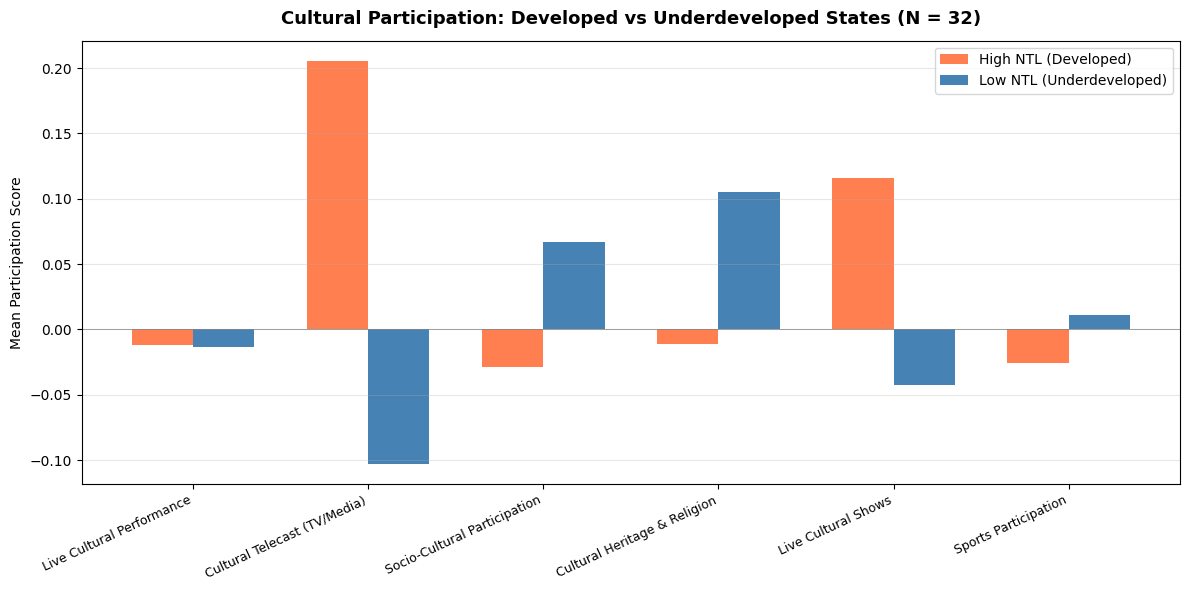


Mann-Whitney U Tests (High NTL vs Low NTL)
Live Cultural Performance           U =    102  p = 0.337   
Cultural Telecast (TV/Media)        U =    204  p = 0.004 *
Socio-Cultural Participation        U =     90  p = 0.158   
Cultural Heritage & Religion        U =    100  p = 0.300   
Live Cultural Shows                 U =    175  p = 0.080  .
Sports Participation                U =    115  p = 0.638   


In [ ]:
# Split states into high/low development groups
median_ntl = gdf["ln_ntl_pc"].median()
gdf["dev_group"] = np.where(
    gdf["ln_ntl_pc"] >= median_ntl, "High NTL", "Low NTL"
)

print(f"Median log NTL per capita: {median_ntl:.3f}")
print(f"High NTL group: {(gdf['dev_group'] == 'High NTL').sum()} states")
print(f"Low NTL group: {(gdf['dev_group'] == 'Low NTL').sum()} states")

# Group means
group_means = gdf.groupby("dev_group")[variables].mean()
print("\nMean Cultural Participation by Development Group")
print("=" * 70)
# Rename index for display
display_means = group_means.T.copy()
display_means.index = [var_labels[v] for v in display_means.index]
print(display_means.round(4).to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(variables))
width = 0.35

bars1 = ax.bar(x - width / 2, group_means.loc["High NTL"], width,
               label="High NTL (Developed)", color="coral")
bars2 = ax.bar(x + width / 2, group_means.loc["Low NTL"], width,
               label="Low NTL (Underdeveloped)", color="steelblue")

ax.set_ylabel("Mean Participation Score")
ax.set_title("Cultural Participation: Developed vs Underdeveloped States (N = 32)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels([var_labels[v] for v in variables], rotation=25, ha="right", fontsize=9)
ax.legend(loc="upper right")
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Mann-Whitney U tests
print("\nMann-Whitney U Tests (High NTL vs Low NTL)")
print("=" * 65)
for var in variables:
    high = gdf[gdf["dev_group"] == "High NTL"][var]
    low = gdf[gdf["dev_group"] == "Low NTL"][var]
    u_stat, p_val = stats.mannwhitneyu(high, low, alternative="two-sided")
    sig = "*" if p_val < 0.05 else (" ." if p_val < 0.10 else "  ")
    print(f"{var_labels[var]:<35} U = {u_stat:>6.0f}  p = {p_val:.3f} {sig}")

## 7. Key Graphs

The two figures below are designed for inclusion in the manuscript. They illustrate the core finding: economic development (proxied by nighttime lights per capita) is **positively** associated with media-based cultural consumption and **negatively** associated with community-based cultural participation.

- **Figure 1** shows the scatter-plot relationship for the two key cultural variables.
- **Figure 2** compares LISA spatial clusters of economic activity with those of the key cultural variables.

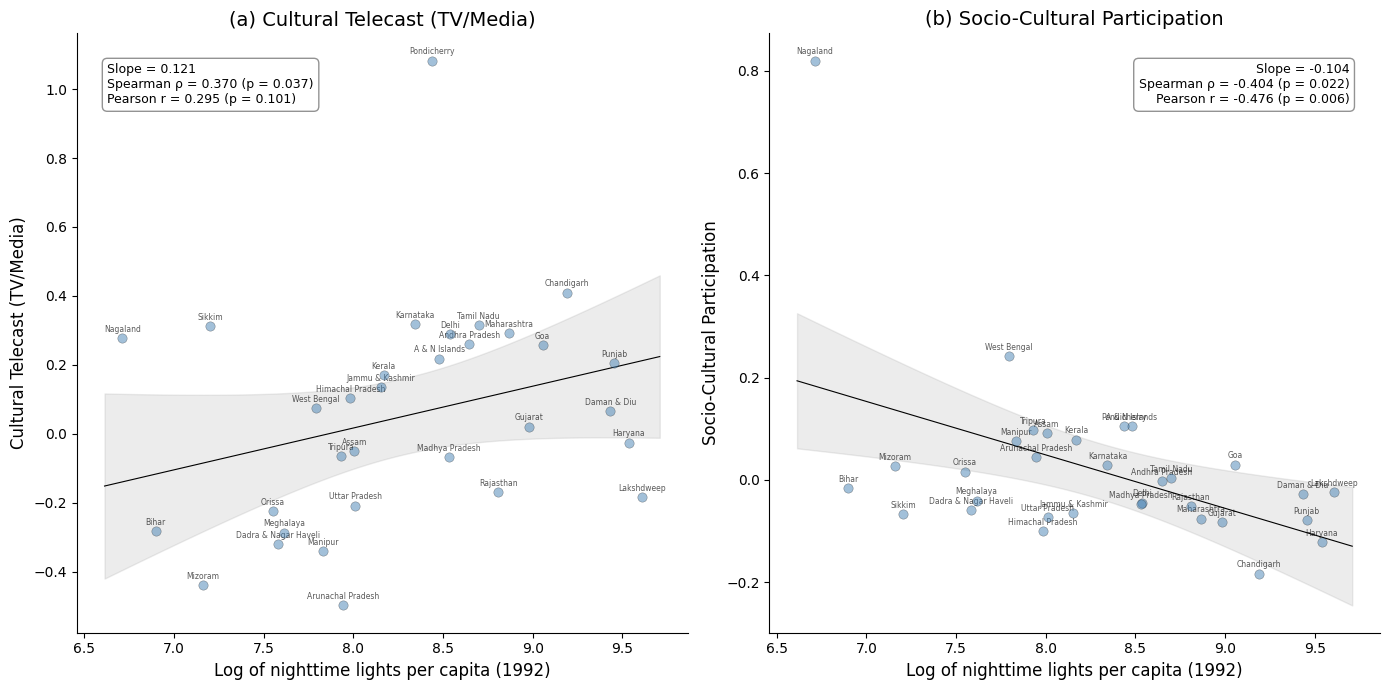

In [ ]:
#| label: fig-culture-scatter
#| fig-cap: "Relationship between nightlight luminosity and cultural participation across 32 Indian states <br> Notes: Each point represents one of the 32 Indian states and union territories. Panel (a) shows the bivariate relationship between log nighttime lights per capita and cultural telecast (TV/media); Panel (b) shows the relationship with socio-cultural participation. Solid line is the OLS regression; gray band shows the 95% confidence interval (t-distribution, 30 df). Annotations report regression slope, Spearman rank correlation, and Pearson correlation. <br> Source: Nighttime lights from CCNL DMSP-OLS (Zhao et al., 2022). Cultural participation from NSS 47th Round (July--December 1991). See [Spatial culture](https://quarcs-lab.github.io/project2025s-py/notebooks/c06_spatial_culture.html) notebook for source code."

# Key variables for the core message
key_vars = ["LC_Telecast", "SC"]
key_labels = {
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "SC": "Socio-Cultural Participation",
}
panel_titles = ["(a) Cultural Telecast (TV/Media)", "(b) Socio-Cultural Participation"]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for i, var in enumerate(key_vars):
    ax = axes[i]
    x = gdf["ln_ntl_pc"]
    y = gdf[var]

    # Scatter points (steelblue to match manuscript style)
    ax.scatter(x, y, s=45, alpha=0.5, color="steelblue", edgecolors="black", linewidth=0.3, zorder=5)

    # Regression line with confidence band
    slope, intercept, r_val, p_val, se = stats.linregress(x, y)
    x_line = np.linspace(x.min() - 0.1, x.max() + 0.1, 200)
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, color="black", linewidth=0.8, zorder=4)

    # Confidence band (95%)
    n = len(x)
    x_mean = x.mean()
    se_fit = np.sqrt(((y - (intercept + slope * x))**2).sum() / (n - 2)) * \
             np.sqrt(1/n + (x_line - x_mean)**2 / ((x - x_mean)**2).sum())
    t_crit = stats.t.ppf(0.975, n - 2)
    ax.fill_between(x_line, y_line - t_crit * se_fit, y_line + t_crit * se_fit,
                    alpha=0.15, color="gray", zorder=3)

    # Label each state
    for _, row in gdf.iterrows():
        ax.annotate(
            row["region"], (row["ln_ntl_pc"], row[var]),
            fontsize=5.5, alpha=0.65, ha="center", va="bottom",
            xytext=(0, 3), textcoords="offset points",
        )

    # Spearman correlation
    rho, p_spearman = stats.spearmanr(x, y)

    # Annotation box (top-left or top-right depending on slope sign)
    box_x = 0.95 if slope < 0 else 0.05
    box_ha = "right" if slope < 0 else "left"
    ax.annotate(
        f"Slope = {slope:.3f}\n"
        f"Spearman \u03c1 = {rho:.3f} (p = {p_spearman:.3f})\n"
        f"Pearson r = {r_val:.3f} (p = {p_val:.3f})",
        xy=(box_x, 0.95), xycoords="axes fraction",
        fontsize=9, ha=box_ha, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.85),
    )

    ax.set_title(panel_titles[i], fontsize=14)
    ax.set_xlabel("Log of nighttime lights per capita (1992)", fontsize=12)
    ax.set_ylabel(key_labels[var], fontsize=12)

    # Minimal style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

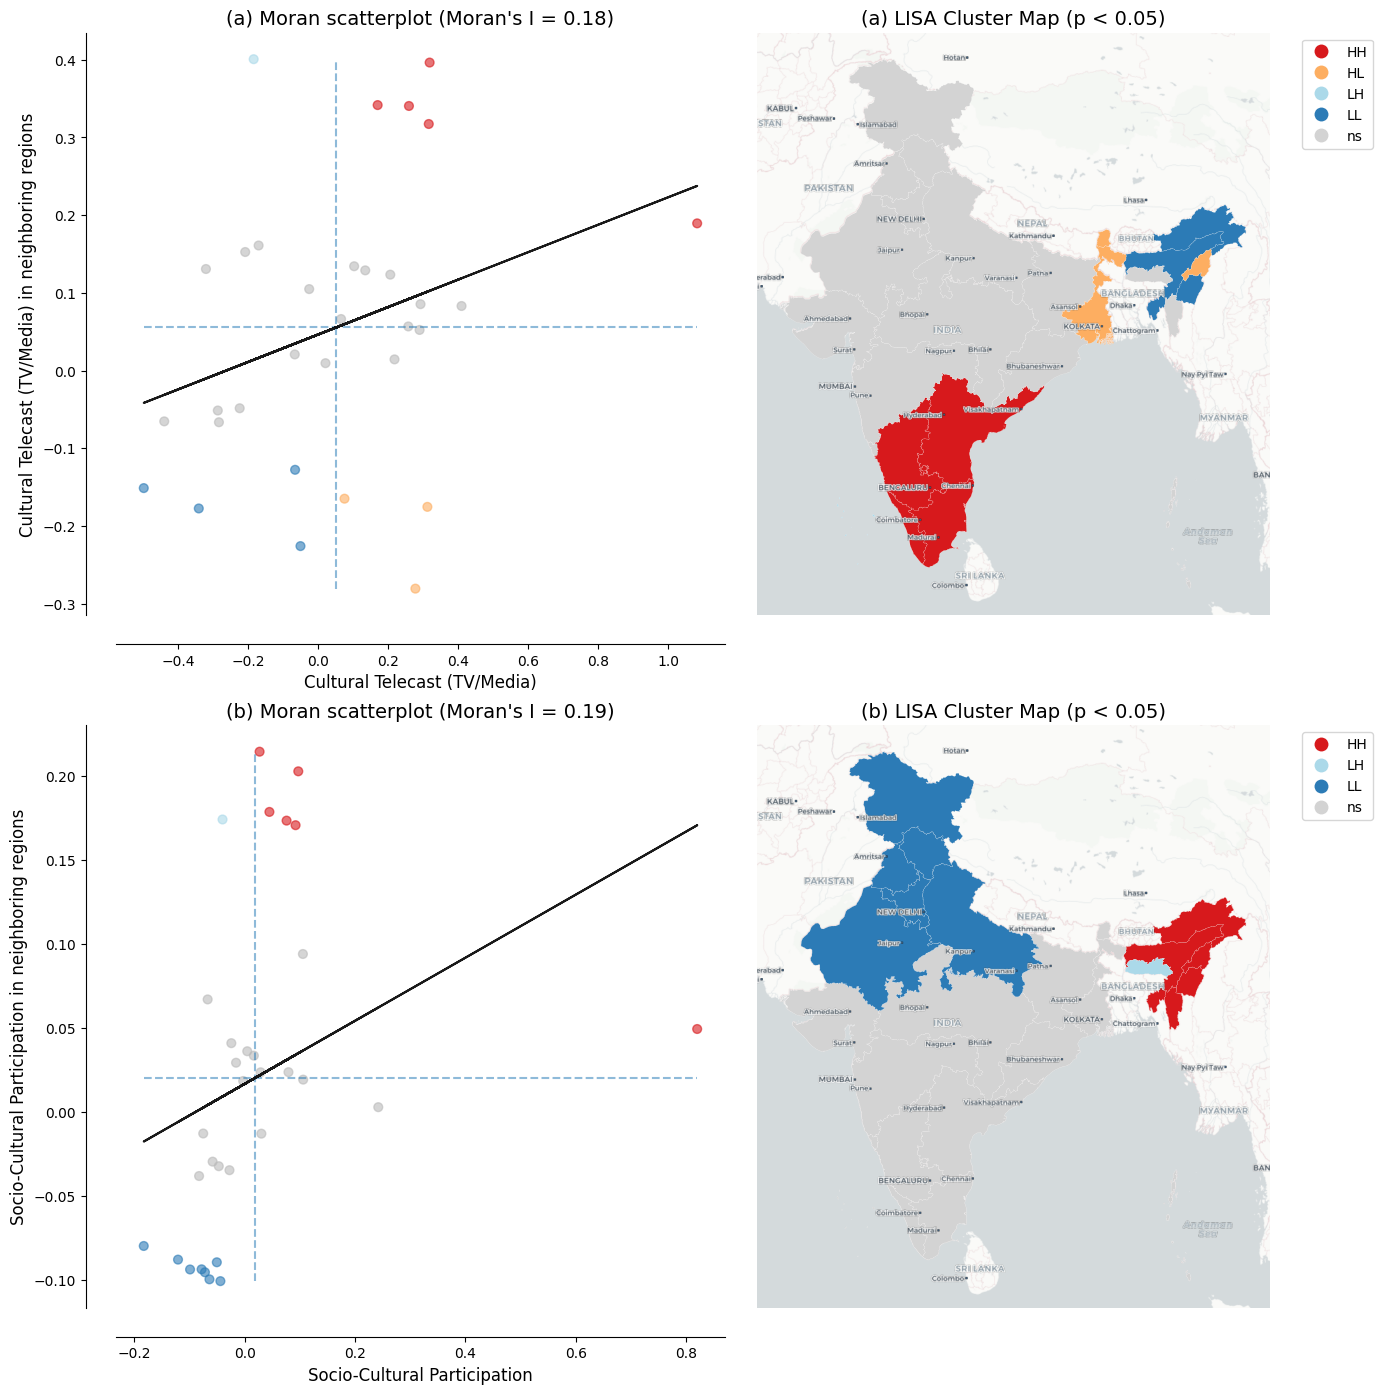

In [ ]:
#| label: fig-culture-lisa
#| fig-cap: "LISA cluster maps of cultural participation across 32 Indian states <br> Notes: Panel (a) shows results for cultural telecast (TV/media); Panel (b) for socio-cultural participation. Left subpanels show Moran scatterplots with the Global Moran's I statistic. Right subpanels show LISA cluster maps with statistically significant clusters at p < 0.05 based on 999 permutations and a 6-nearest-neighbors spatial weights matrix. Region labels are overlaid from the CartoDB Positron basemap. <br> Source: Cultural participation data from NSS 47th Round (July--December 1991). See [Spatial culture](https://quarcs-lab.github.io/project2025s-py/notebooks/c06_spatial_culture.html) notebook for source code."

# Reproject to Web Mercator for basemap overlay
gdf_wm = gdf.to_crs(epsg=3857)

# Two key cultural variables only
lisa_vars = ["LC_Telecast", "SC"]
lisa_labels = {
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "SC": "Socio-Cultural Participation",
}
panel_rows = ["(a)", "(b)"]

# Compute LISA for each variable
lisa_objects = {}
moran_globals = {}
for var in lisa_vars:
    lisa_objects[var] = Moran_Local(gdf_wm[var].values, W, permutations=999, seed=12345)
    moran_globals[var] = Moran(gdf_wm[var].values, W, permutations=999)

# Create 2-row x 2-column figure
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for i, var in enumerate(lisa_vars):
    moranI = f"{moran_globals[var].I:.2f}"

    # Left panel: Moran scatterplot
    moran_scatterplot(lisa_objects[var], p=0.05, zstandard=False, aspect_equal=False, ax=axes[i, 0])
    axes[i, 0].set_title(
        f"{panel_rows[i]} Moran scatterplot (Moran's I = {moranI})", fontsize=14
    )
    axes[i, 0].set_xlabel(lisa_labels[var], fontsize=12)
    axes[i, 0].set_ylabel(f"{lisa_labels[var]} in neighboring regions", fontsize=12)
    axes[i, 0].tick_params(labelsize=10)

    # Right panel: LISA cluster map
    lisa_cluster(
        lisa_objects[var], gdf_wm, p=0.05,
        legend_kwds={"bbox_to_anchor": (1.05, 1), "loc": "upper left"},
        ax=axes[i, 1],
    )
    axes[i, 1].set_title(
        f"{panel_rows[i]} LISA Cluster Map (p < 0.05)", fontsize=14
    )

    # Add CartoDB basemap (matching manuscript style)
    cx.add_basemap(
        axes[i, 1], crs=gdf_wm.crs.to_string(),
        source=cx.providers.CartoDB.Positron, attribution=False,
    )
    cx.add_basemap(
        axes[i, 1], crs=gdf_wm.crs.to_string(),
        source=cx.providers.CartoDB.PositronOnlyLabels, attribution=False,
    )
    axes[i, 1].set_axis_off()

plt.tight_layout()
plt.show()
